In [1]:
%load_ext autoreload
%autoreload 2

In [121]:
import numpy as np

import matplotlib.pyplot as plt
from time import time
from mad.configs.ballistic_objects import titan_stage_1, titan_stage_2
from mad.configs.planets import EARTH_SETTINGS
from mad.objs.planets import Planet, PlanetConfig
from mad.objs.missiles import BallisticMissileConfig, MissileStage, MissileStageConfig, BallisticMissile, Payload
from mad.objs.guidances import GravityTurn, ClosedFormBallistic, RangeGuided
from mad.logger import SourceLogger


logger = SourceLogger()

In [143]:
EARTH_SETTINGS["position"] = [0.0, 0.0]

earth = Planet(PlanetConfig(**EARTH_SETTINGS))
launchpad = earth.create_2D_point(name="Launchpad", altitude=10)
target = earth.create_2D_point_at_distance(launchpad, distance_km=1_000, name="Target")

earth

Planet Earth at [0. 0. 0.]
Mass 5.97e+24 kg, Radius 6371.0 km.
Gravity at surface: -9.82 m/s^2
Orbital velocity: 7909.55 m/s
Escape velocity: 11185.79 m/s

In [144]:
stage1_cfg = MissileStageConfig(**titan_stage_1)
stage2_cfg = MissileStageConfig(**titan_stage_2)

guidance = RangeGuided(planet=earth, target=target, ballistic_table_path="titan_stage_2")

stage1 = MissileStage(stage1_cfg)
stage2 = MissileStage(stage2_cfg)

missile_cfg = BallisticMissileConfig(stages=[stage1, stage2], guidance=guidance)
titan = BallisticMissile(position=launchpad.position.copy(), cfg=missile_cfg, name="Titan I")

titan

BallisticMissile Titan I, active.
Stages: Stage1, Stage2.
Available deltaV: 11818.37 m/s.
Burned Fraction: 0.00.

In [145]:
dt = 1.0
max_time = 20_000
active_objs = [titan]
t = 0.0
logger["Simulation"].info("Starting simulation.")
start = time()
while (t < max_time) and any(obj.active for obj in active_objs):
    new_objects = []

    for obj in active_objs[:]:

        if not obj.active:
            continue

        sim_update = obj.update(dt)

        if sim_update is not None:
            new_objects.append(sim_update)
            logger["Simulation"].info(f"{sim_update.name} added to Simulation.")

        if not obj.active:
            continue
        obj.integrate(dt, earth)

    active_objs.extend(new_objects)
    t += dt
stop = time()
logger["Simulation"].info(f"Simulation ended at t={t:.2f} seconds. Took {stop - start:.2f} seconds of real time.")

16:41:35 | INFO     | Simulation   | Starting simulation.


16:41:35 | INFO     | Missile      | Stage1 ran out of propellant at 110.00.
16:41:35 | INFO     | Missile      | Titan I - Stage1 separated at 110.00.
16:41:35 | INFO     | Simulation   | Stage1 added to Simulation.
16:41:35 | DEBUG    | Guidance     | Target range 759570.79 reached at Table index: 8053, table values: {'altitude_m': '150000.00', 'velocity_m_s': '3000.00', 'gamma_rad': '0.45', 'range_rad': '0.16'}.
16:41:35 | INFO     | Missile      | Titan I switched to ballistic phase at 215.00.
16:41:35 | INFO     | Missile      | Titan I - Stage2 separated at 215.00.
16:41:35 | INFO     | Missile      | Titan I inactivated at 215.00.
16:41:35 | INFO     | Simulation   | Stage2 added to Simulation.
16:41:35 | INFO     | Projectile   | Stage1 landed on the ground!
16:41:35 | INFO     | Projectile   | Stage2 landed on the ground!
16:41:35 | INFO     | Simulation   | Simulation ended at t=948.00 seconds. Took 0.29 seconds of real time.


In [146]:
def extract_history(objs:list, planet:Planet=earth):

    results = {}
    for obj in objs:
        pos = np.asarray(obj.history.position)
        vel = np.asarray(obj.history.velocity)
        time = np.asarray(obj.history.time)
        gamma = np.asarray([x for x in obj.history.gamma if x is not None]) if obj.history.gamma else None

        posx, posz = pos[:, 0], pos[:, 1]

        r = np.linalg.norm(pos, axis=1)
        velout = np.linalg.norm(vel, axis=1)

        energy = 0.5 * velout**2 - planet.mu / r
        altitude = r - planet.radius

        results[obj.name] = {
            "time": time,
            "altitude": altitude,
            "velocity": velout,
            "posx": posx,
            "posz": posz,
            "energy": energy,
        }
        if gamma is not None:
            results[obj.name]["gamma"] = gamma

    return results

results = extract_history(active_objs, planet=earth)
results.keys()

dict_keys(['Titan I', 'Stage1', 'Stage2'])

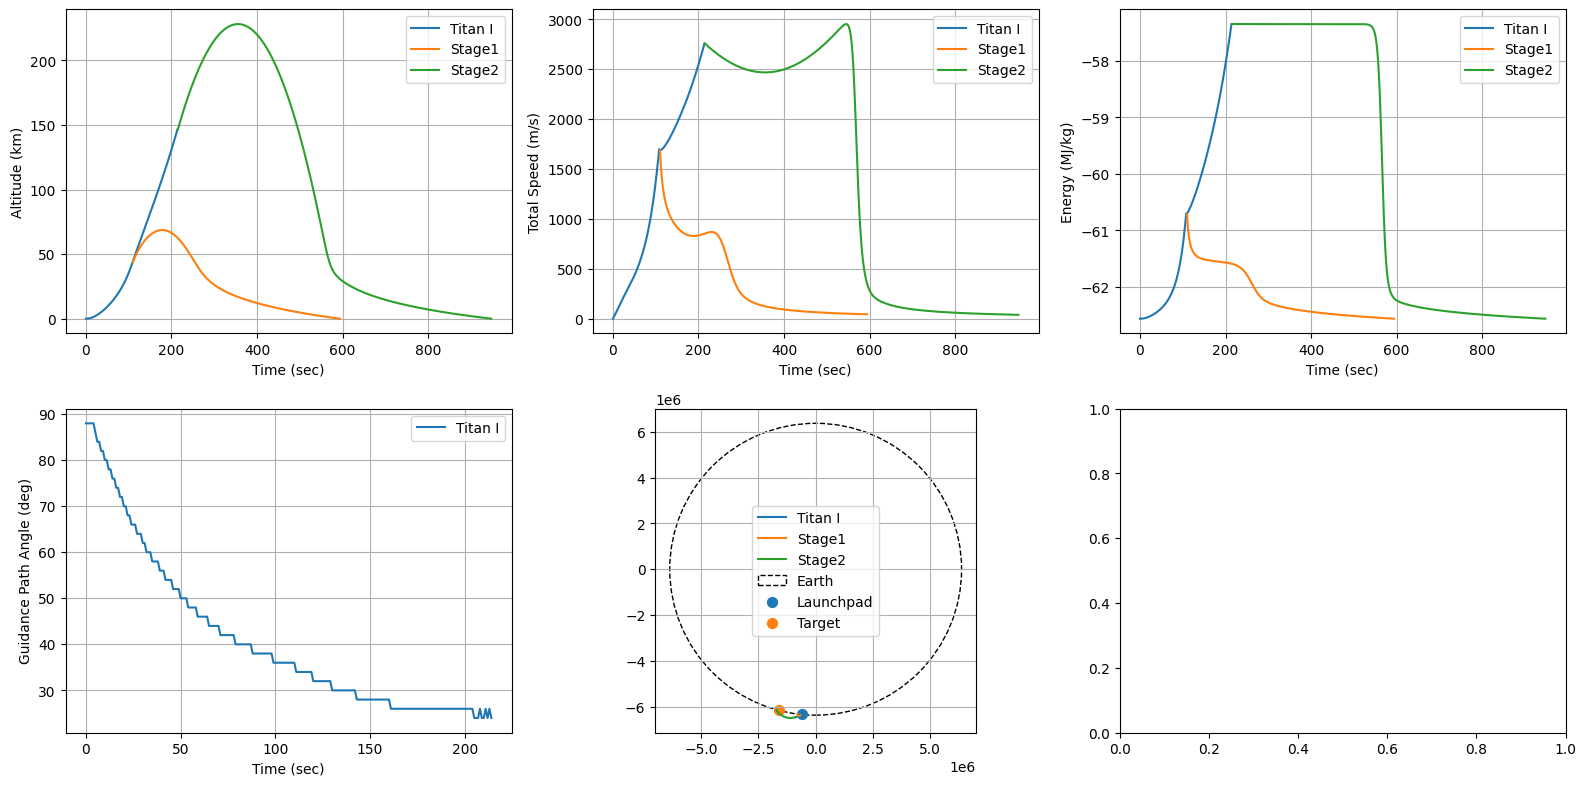

In [147]:
fig, ax = plt.subplots(ncols=3, nrows=2, figsize=(16, 8))
ax = ax.ravel()

for obj, result in results.items():

    ax[0].plot(result["time"], result["altitude"] / 1000, label=obj)
    ax[1].plot(result["time"], result["velocity"], label=obj)
    ax[2].plot(result["time"], result["energy"] / 1000_000, label=obj)
    if "gamma" in result:
        ax[3].plot(result["time"], np.degrees(result["gamma"]), label=obj)
    ax[4].plot(result["posx"], result["posz"], label=obj)

ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (km)")
ax[0].grid()
ax[0].legend()

ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")
ax[1].legend()
ax[1].grid()

ax[2].set_xlabel("Time (sec)")
ax[2].set_ylabel("Energy (MJ/kg)")
ax[2].legend()
ax[2].grid()

ax[3].set_xlabel("Time (sec)")
ax[3].set_ylabel("Guidance Path Angle (deg)")
ax[3].legend()
ax[3].grid()

earth.plot_2D_with_points(points = [launchpad, target], ax=ax[4])


fig.tight_layout(pad=1.2)

In [148]:
f"Distance Impact to target: {earth.surface_distance(target, active_objs[2]) / 1000:.2f} km"

'Distance Impact to target: 108.82 km'

In [80]:
[x.active for x in active_objs]

[False, False, False]